<h1>WWTW CNN — Aerobic Zone / Clarifier Classifier</h1>

This notebook trains a CNN in PyTorch to classify cropped satellite images of WWTW
process units (aerobic zones or clarifiers) into their functional state, using the
dataset produced by `prepare_cnn_dataset.py`.

**Structure:**
1. Imports & config
2. Load dataset (`ImageFolder`) and split into train / validation / test
3. Inspect a batch of images
4. Define the CNN
5. Train (with early stopping)
6. Evaluate (accuracy + confusion matrix)
7. Save the trained model

Set `COMPONENT` below to `"aerobic_zone"` or `"clarifier"` depending on which
classifier you're training — everything else adapts automatically based on how
many class folders are found.

**Note on image shape:** aerobic zone crops are rectangular (roughly 2:1,
width:height) rather than square, since that's the actual shape of the aerated
basins. Resizing them to a square would distort the surface texture the model
relies on (the "leopard print" pattern), so this notebook resizes to a fixed
*rectangle* matching that aspect ratio instead. Clarifier crops, being circular
regions, stay closer to square.

In [3]:
# preamble - imports
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from pathlib import Path
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


# 1. Config

Points at the output of `prepare_cnn_dataset.py`. Switch `COMPONENT` to
`"clarifier"` to train that classifier instead — no other changes needed.

`IMG_TARGET_SIZE` is a `(height, width)` pair per component, chosen to match
the real aspect ratio of each crop type rather than forcing a square.

In [4]:
# ------------------------- CONFIG -------------------------

DATASET_ROOT = Path("../cnn_dataset")   # adjust if your output folder is elsewhere
COMPONENT = "aerobic_zone"              # "aerobic_zone" or "clarifier"

# (height, width) — aerobic zones are ~2:1 (wide rectangles), clarifiers are
# closer to square since they're circular tank crops. Adjust if your actual
# crop aspect ratios differ noticeably — check a few images if unsure.
IMG_TARGET_SIZE = {
    "aerobic_zone": (96, 192),
    "clarifier": (128, 128),
}[COMPONENT]

BATCH_SIZE = 32
LR = 1e-3
WEIGHT_DECAY = 1e-4     # L2 regularization — helps reduce the train/val gap
EPOCHS = 100
EARLY_STOP_PATIENCE = 10   # stop if val loss hasn't improved for this many epochs
VAL_FRACTION = 0.15
TEST_FRACTION = 0.15
SEED = 42

MODEL_SAVE_PATH = Path(f"../models/{COMPONENT}_cnn.pt")

# ------------------------------------------------------------------

data_dir = DATASET_ROOT / COMPONENT
assert data_dir.exists(), f"Dataset folder not found: {data_dir}. Run prepare_cnn_dataset.py first."

torch.manual_seed(SEED)

# 2. Load dataset

`ImageFolder` treats each subfolder name as a class label — this lines up
directly with the `Functional/`, `Suboptimal/`, `Dysfunctional/`, etc. folders
produced by `prepare_cnn_dataset.py`.

Train and eval use different transforms (train gets augmentation), so we build
two `ImageFolder` instances over the same data and split by *indices* to keep
the same images in each split for both.

In [5]:
train_transform = transforms.Compose([
    transforms.Resize(IMG_TARGET_SIZE),   # (height, width) — preserves the rectangle, no square distortion
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),  # satellite images vary by season/capture date
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],   # ImageNet stats — fine as a default starting point
                          std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize(IMG_TARGET_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])

full_dataset_train_tf = datasets.ImageFolder(root=data_dir, transform=train_transform)
full_dataset_eval_tf = datasets.ImageFolder(root=data_dir, transform=eval_transform)

class_names = full_dataset_train_tf.classes
num_classes = len(class_names)
print(f"Classes found ({num_classes}): {class_names}")

n_total = len(full_dataset_train_tf)
n_val = int(n_total * VAL_FRACTION)
n_test = int(n_total * TEST_FRACTION)
n_train = n_total - n_val - n_test

generator = torch.Generator().manual_seed(SEED)
train_idx, val_idx, test_idx = random_split(
    range(n_total), [n_train, n_val, n_test], generator=generator
)

train_ds = torch.utils.data.Subset(full_dataset_train_tf, train_idx.indices)
val_ds = torch.utils.data.Subset(full_dataset_eval_tf, val_idx.indices)
test_ds = torch.utils.data.Subset(full_dataset_eval_tf, test_idx.indices)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1205 | Val: 258 | Test: 258


## Check class balance

Worth looking at before training — if one class dominates, plain accuracy
will be misleading and you may want class weighting in the loss function.

  Dysfunctional  : 805
  Functional     : 693
  Suboptimal     : 223


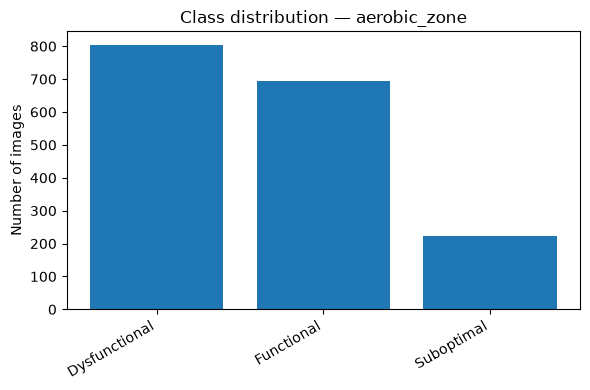

In [6]:
counts = np.bincount([label for _, label in full_dataset_train_tf.samples], minlength=num_classes)
for name, count in zip(class_names, counts):
    print(f"  {name:15s}: {count}")

plt.figure(figsize=(6, 4))
plt.bar(class_names, counts)
plt.ylabel("Number of images")
plt.title(f"Class distribution — {COMPONENT}")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# 3. Inspect a batch

Quick sanity check that images and labels are loading correctly, and that
the rectangular resize looks right (no obvious squishing) before spending
time training.

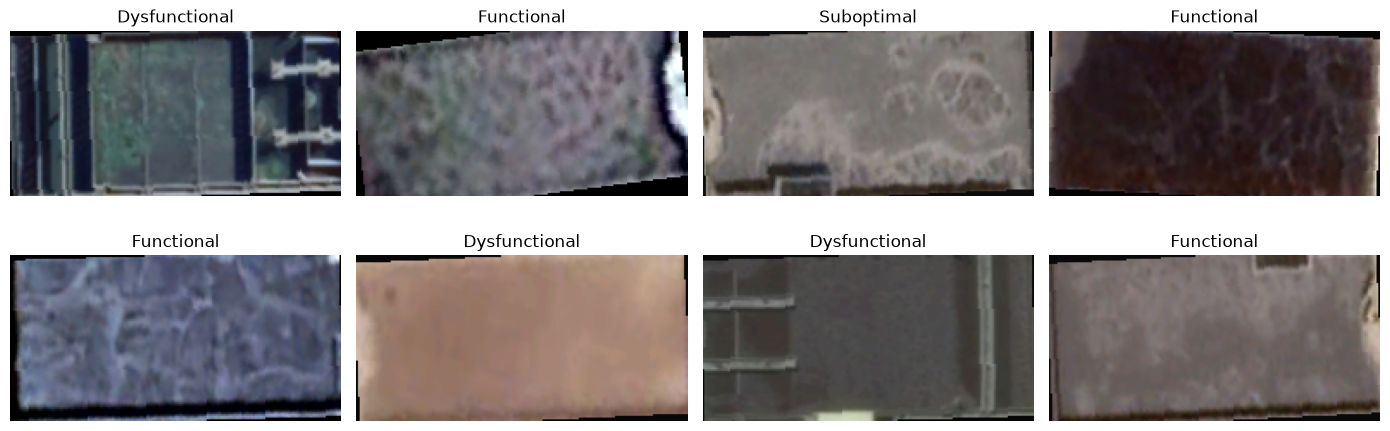

In [7]:
def denormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (img_tensor * std + mean).clamp(0, 1)

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(14, 5))
for ax, img, label in zip(axes.flatten(), images, labels):
    ax.imshow(denormalize(img).permute(1, 2, 0).numpy())
    ax.set_title(class_names[label])
    ax.axis("off")
plt.tight_layout()
plt.show()

# 4. Define the CNN

Three conv blocks (conv → batchnorm → ReLU → max-pool), followed by
`AdaptiveAvgPool2d` and two fully-connected layers.

Using `AdaptiveAvgPool2d` instead of manually computing the flattened size
means the model works with whatever `IMG_TARGET_SIZE` you set — including
non-square input — without needing to recalculate tensor dimensions by hand.

In [8]:
class WWTW_CNN(nn.Module):
    def __init__(self, num_classes, pooled_size=4):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        # Collapses whatever spatial size comes out of `features` down to a
        # fixed pooled_size x pooled_size, regardless of input aspect ratio
        self.pool = nn.AdaptiveAvgPool2d((pooled_size, pooled_size))

        flat_features = 64 * pooled_size * pooled_size

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_features, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        y_hat = self.classifier(x)
        return y_hat

# 5. Instantiate model, loss, and optimizer

`CrossEntropyLoss` expects raw logits (no softmax needed in the model output).
`weight_decay` on the optimizer adds L2 regularization, which helps narrow the
train/val gap alongside dropout.

In [9]:
model = WWTW_CNN(num_classes=num_classes).to(device)
print(model)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

WWTW_CNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveAvgPool2d(output_size=(4, 4))
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(

# 6. Training loop, with early stopping

Given that overfitting showed up around epoch 50 in the previous run, this
version tracks validation loss each epoch and keeps the best-performing model
state in memory. Training stops automatically once val loss hasn't improved
for `EARLY_STOP_PATIENCE` epochs in a row, so you don't need to guess the
right epoch count up front — `EPOCHS` just acts as an upper bound.

In [ ]:
def run_epoch(loader, train_mode):
    model.train() if train_mode else model.eval()

    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train_mode):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            if train_mode:
                optimizer.zero_grad()

            y_hat = model(images)
            loss = criterion(y_hat, labels)

            if train_mode:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            correct += (y_hat.argmax(dim=1) == labels).sum().item()
            total += images.size(0)

    return total_loss / total, correct / total


history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

best_val_loss = float("inf")
best_model_state = None
epochs_without_improvement = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, train_mode=True)
    val_loss, val_acc = run_epoch(val_loader, train_mode=False)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    improved = val_loss < best_val_loss
    if improved:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    flag = " *" if improved else ""
    print(f"Epoch {epoch:3d}/{EPOCHS} | "
          f"train loss {train_loss:.4f} acc {train_acc:.3f} | "
          f"val loss {val_loss:.4f} acc {val_acc:.3f}{flag}")

    if epochs_without_improvement >= EARLY_STOP_PATIENCE:
        print(f"\nNo val loss improvement for {EARLY_STOP_PATIENCE} epochs — stopping early at epoch {epoch}.")
        break

# Restore the best checkpoint (lowest val loss), not just whatever the last epoch happened to be
model.load_state_dict(best_model_state)
print(f"\nRestored model from best epoch (val loss = {best_val_loss:.4f})")

Epoch   1/100 | train loss 0.9783 acc 0.532 | val loss 0.8443 acc 0.609 *
Epoch   2/100 | train loss 0.8394 acc 0.651 | val loss 0.7444 acc 0.674 *
Epoch   3/100 | train loss 0.7796 acc 0.687 | val loss 0.6819 acc 0.729 *
Epoch   4/100 | train loss 0.7342 acc 0.716 | val loss 0.6134 acc 0.733 *
Epoch   5/100 | train loss 0.7151 acc 0.723 | val loss 0.6136 acc 0.733
Epoch   6/100 | train loss 0.6843 acc 0.723 | val loss 0.6251 acc 0.740
Epoch   7/100 | train loss 0.6784 acc 0.721 | val loss 0.5734 acc 0.764 *
Epoch   8/100 | train loss 0.7101 acc 0.722 | val loss 0.6076 acc 0.721
Epoch   9/100 | train loss 0.6497 acc 0.742 | val loss 0.6119 acc 0.729
Epoch  10/100 | train loss 0.6677 acc 0.736 | val loss 0.5986 acc 0.740
Epoch  11/100 | train loss 0.6166 acc 0.754 | val loss 0.6063 acc 0.752
Epoch  12/100 | train loss 0.6301 acc 0.746 | val loss 0.5890 acc 0.752
Epoch  13/100 | train loss 0.6196 acc 0.755 | val loss 0.5719 acc 0.760 *
Epoch  14/100 | train loss 0.6216 acc 0.739 | val lo

## Training curves

The vertical line marks the epoch that was restored (lowest validation
loss). Everything past that point is where the model was starting to
overfit.

In [ ]:
best_epoch = int(np.argmin(history["val_loss"])) + 1

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].axvline(best_epoch - 1, color="gray", linestyle="--", linewidth=1, label="restored checkpoint")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].axvline(best_epoch - 1, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

# 7. Evaluate on the test set

Test set was held out entirely from training/validation, so this gives an
unbiased read on final performance, using the restored best checkpoint rather
than whichever epoch training happened to stop on. The confusion matrix is
worth reading closely here — for this problem, false "Functional" calls on a
genuinely Dysfunctional unit matter more than the reverse, so it's worth
checking which direction the model's mistakes lean.

In [ ]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        y_hat = model(images)
        preds = y_hat.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

test_acc = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"Test accuracy: {test_acc:.3f}")

# Force the matrix to build a grid for all known classes using their integer indices (0 to 3)
cm = confusion_matrix(all_labels, all_preds, labels=range(len(class_names)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=30)
plt.title(f"Confusion matrix — {COMPONENT} test set")
plt.tight_layout()
plt.show()

## Per-class precision, recall, and F1

The confusion matrix shows *where* mistakes happen; this breaks it down into
per-class numbers. Recall matters most for the "Dysfunctional" class in
particular — missing a genuinely dysfunctional unit (low recall) is a worse
failure mode for this application than a false alarm (low precision).

In [ ]:
from sklearn.metrics import classification_report

# Added 'labels' to define the 4x4 structure, and 'zero_division' to suppress warnings for the Empty class
print(classification_report(
    all_labels, 
    all_preds, 
    labels=range(len(class_names)), 
    target_names=class_names, 
    digits=3, 
    zero_division=0
))

## Precision-recall curves and Average Precision (AUC)

Since this is a multi-class problem, each class gets its own one-vs-rest
curve: "this class" vs. "everything else," using the model's predicted
probability for that class.

A PR curve is generated by sweeping the decision threshold across the full
range of predicted probabilities and recomputing precision/recall at each
point — no single threshold is chosen up front. **Average Precision (AP)**,
shown in the legend, is the area under that curve: a single threshold-free
number summarizing performance across every possible cutoff. Higher is
better, with 1.0 being a perfect classifier for that class.

This needs raw probabilities (not just the predicted class), so the test set
is passed through the model again to collect them.

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

model.eval()
all_probs = []
all_labels_full = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        y_hat = model(images)
        probs = torch.softmax(y_hat, dim=1).cpu().numpy()
        all_probs.append(probs)
        all_labels_full.extend(labels.numpy())

all_probs = np.concatenate(all_probs, axis=0)
all_labels_full = np.array(all_labels_full)

# One-vs-rest binarized labels: one column per class, 1 if that's the true class
y_true_bin = label_binarize(all_labels_full, classes=list(range(num_classes)))

plt.figure(figsize=(7, 6))
average_precisions = {}

for i, name in enumerate(class_names):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], all_probs[:, i])
    ap = average_precision_score(y_true_bin[:, i], all_probs[:, i])
    average_precisions[name] = ap
    plt.plot(recall, precision, label=f"{name} (AP = {ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall curves — {COMPONENT} (test set)")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Average Precision (area under PR curve) per class:")
for name, ap in average_precisions.items():
    print(f"  {name:15s}: {ap:.3f}")
print(f"\nMean Average Precision (mAP): {np.mean(list(average_precisions.values())):.3f}")

# 8. Save the trained model

In [ ]:
MODEL_SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)
torch.save({
    "model_state_dict": model.state_dict(),
    "class_names": class_names,
    "img_target_size": IMG_TARGET_SIZE,
    "component": COMPONENT,
}, MODEL_SAVE_PATH)

print(f"Saved model to {MODEL_SAVE_PATH}")

# Next steps

Some things worth trying from here:

- **Class imbalance** — if the class distribution plot above is skewed (likely,
  given Dysfunctional/Suboptimal counts differ a lot from Functional), try
  `nn.CrossEntropyLoss(weight=...)` with inverse-frequency class weights, or
  oversampling the minority classes.
- **If it's still overfitting even with early stopping** — that usually means
  the model has more capacity than the dataset can support. Try reducing the
  channel counts in `WWTW_CNN`, increasing dropout further, or adding more
  aggressive augmentation (e.g. `RandomResizedCrop` instead of a plain resize).
- **Transfer learning** — swap `WWTW_CNN` for a pretrained backbone
  (`torchvision.models.resnet18(weights="IMAGENET1K_V1")`) with the final layer
  replaced, especially if the dataset stays a few hundred images per class.
  Pretrained features tend to overfit less on small datasets than training
  from scratch.
- **Cross-facility generalisation** — since the thesis scope covers three
  facilities, it's worth checking whether training on two facilities and
  testing on the third holds up, not just a random split across all three.
- **Grad-CAM / filter visualisation** — visualising which parts of the image
  the CNN attends to would make a strong addition to the Results chapter, and
  doubles as a sanity check that it's actually looking at the aerator/clarifier
  surface and not some unrelated artifact (e.g. image borders or watermarks).